# Student Performance Indicator

## Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose Best Model


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw.csv')

In [3]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [4]:
df.isna().sum()



Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(210)

In [6]:
df.drop_duplicates()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
...,...,...,...,...,...,...,...,...,...,...
701,S118,Female,21,69.858192,90,Masters,Yes,No,50,Fail
702,S358,Female,22,93.349688,76,Bachelors,No,No,60,Pass
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail


In [7]:
df = df.drop_duplicates()
print(df)
print(df.duplicated().sum())

    Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  \
0         S147    Male                    31        68.267841   
1         S136    Male                    16        78.222927   
2         S209  Female                    21        87.525096   
3         S458  Female                    27        92.076483   
4         S078  Female                    37        98.655517   
..         ...     ...                   ...              ...   
701       S118  Female                    21        69.858192   
702       S358  Female                    22        93.349688   
703       S492    Male                    14        84.658761   
705       S473    Male                    25        98.384969   
707       S046  Female                    22        80.404392   

     Past_Exam_Scores Parental_Education_Level Internet_Access_at_Home  \
0                  86              High School                     Yes   
1                  73                      PhD                      No 

In [8]:
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  500 non-null    object 
 1   Gender                      500 non-null    object 
 2   Study_Hours_per_Week        500 non-null    int64  
 3   Attendance_Rate             500 non-null    float64
 4   Past_Exam_Scores            500 non-null    int64  
 5   Parental_Education_Level    500 non-null    object 
 6   Internet_Access_at_Home     500 non-null    object 
 7   Extracurricular_Activities  500 non-null    object 
 8   Final_Exam_Score            500 non-null    int64  
 9   Pass_Fail                   500 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 43.0+ KB


Student_ID                    500
Gender                          2
Study_Hours_per_Week           30
Attendance_Rate               500
Past_Exam_Scores               51
Parental_Education_Level        4
Internet_Access_at_Home         2
Extracurricular_Activities      2
Final_Exam_Score               27
Pass_Fail                       2
dtype: int64

In [9]:
# define numerical & categorical columns

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']


# print columns

print("We have {} numerical features : {}".format(len(numeric_features), numeric_features))

print("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 4 numerical features : ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Final_Exam_Score']

We have 6 categorical features : ['Student_ID', 'Gender', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Pass_Fail']


In [10]:
df['total score'] = df['Study_Hours_per_Week'] + df['Attendance_Rate'] + df['Past_Exam_Scores'] + df['Final_Exam_Score']
df['average'] = df['total score']/4
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail,total score,average
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass,248.267841,62.066960
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail,217.222927,54.305732
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail,237.525096,59.381274
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass,283.076483,70.769121
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass,268.655517,67.163879


In [11]:
study_hours_full = df[df['Study_Hours_per_Week'] == 39]['average'].count()
attendance_rate_full = df[df['Attendance_Rate'] == 60]['average'].count()
past_exam_score_full = df[df['Past_Exam_Scores'] == 100]['average'].count()
final_exam_score_full = df[df['Final_Exam_Score'] == 100]['average'].count()

print(f'Number of students with max study hours: {study_hours_full}')
print(f'Number of students with max attendance rate: {attendance_rate_full }')
print(f'Number of students with full marks in past test: {past_exam_score_full }')
print(f'Number of students with full marks in final test: {final_exam_score_full }')


study_hours_full = df[df['Study_Hours_per_Week'] == df['Study_Hours_per_Week'].max()]['average'].count()

attendance_rate_full = df[df['Attendance_Rate'] == df['Attendance_Rate'].max()]['average'].count()


Number of students with max study hours: 17
Number of students with max attendance rate: 0
Number of students with full marks in past test: 8
Number of students with full marks in final test: 0


In [12]:
print(df['Study_Hours_per_Week'].max())
print(df['Attendance_Rate'].max())

print(df[df['Study_Hours_per_Week'] == df['Study_Hours_per_Week'].max()])
print(df[df['Attendance_Rate'] == df['Attendance_Rate'].max()])

39
99.96767497829174
    Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  \
19        S386  Female                    39        85.197307   
30        S155    Male                    39        50.912124   
61        S380    Male                    39        81.662039   
124       S280  Female                    39        89.504232   
197       S277    Male                    39        79.648145   
211       S092  Female                    39        54.614529   
239       S126  Female                    39        61.660821   
267       S488  Female                    39        81.861579   
272       S234  Female                    39        86.527457   
315       S115    Male                    39        51.523608   
323       S103  Female                    39        76.829532   
344       S157    Male                    39        99.862777   
409       S169    Male                    39        91.929128   
410       S398  Female                    39        60.975526   
411 

Exploring Data (Visualization)


Visualizing average score distribution to make some conclusion .
 Histogram
 kernal Distribution Function  

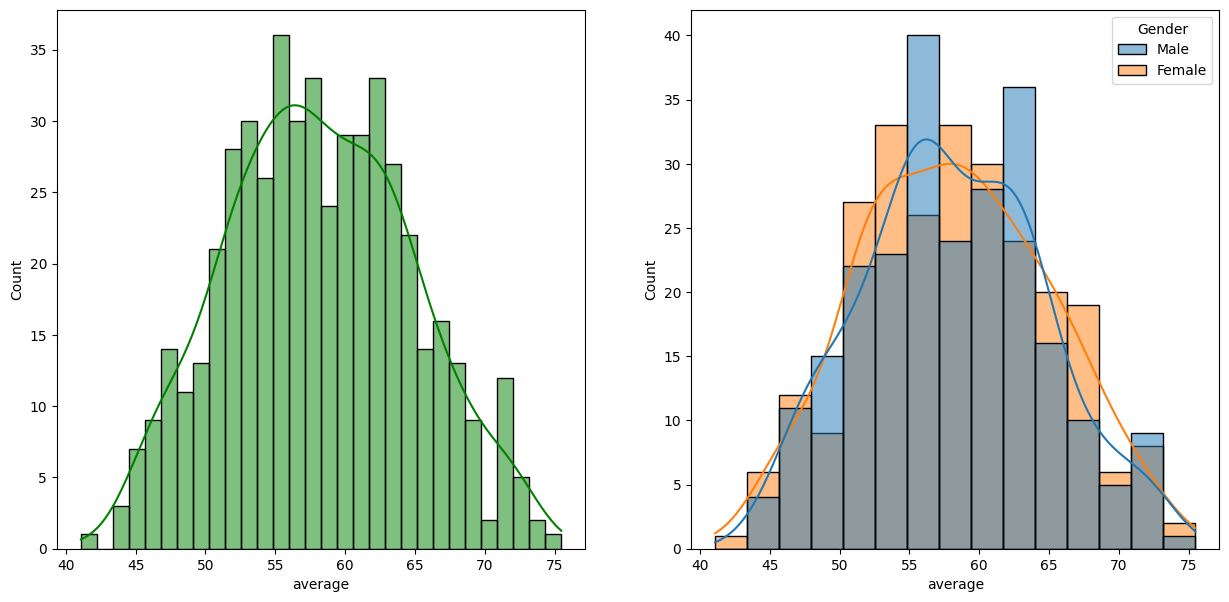

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='Gender')

plt.show()

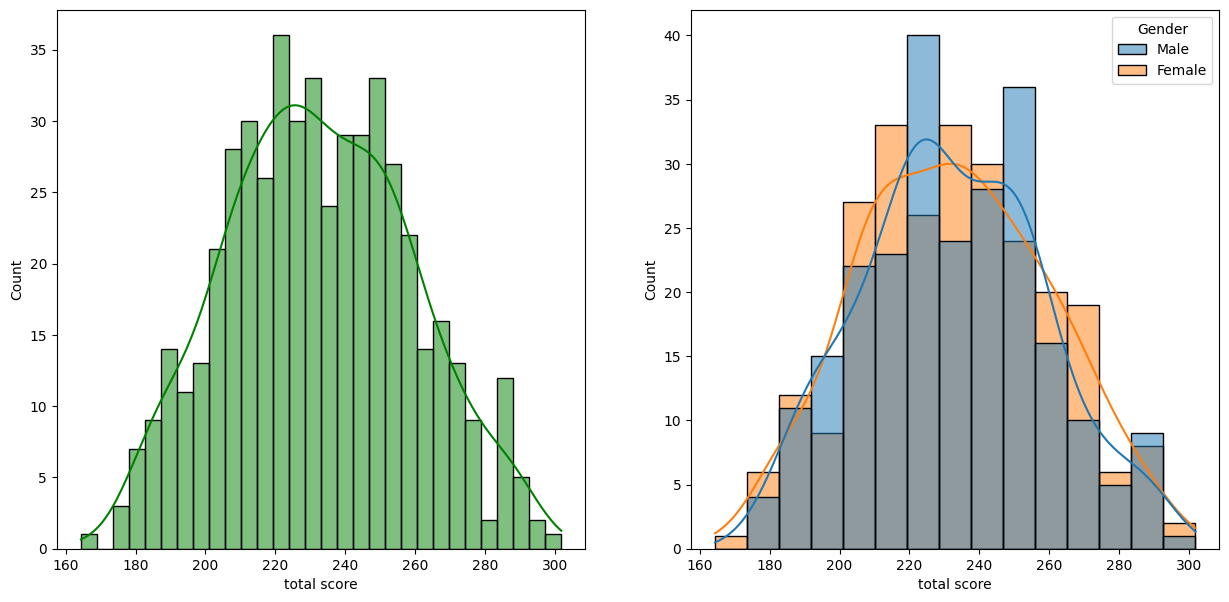

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='total score', kde=True, hue='Gender')

plt.show()